## Data Loading and Preprocessing

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("https://gitlab.crio.do/me_notebook/me_jupyter_bankattritionanalysis/-/raw/master/bank_dataset_v2.csv",header=0,skiprows=[1])

# Display the first few rows
print(df.head())

   Row Number Customer ID First Name        State  Gender  Age    Salary  \
0           2     MH00002      Nitya  Maharashtra  Female   77   33000.0   
1           3     KA00003     Vivaan    Karnataka    Male   78  190000.0   
2           4     MH00004     Dinesh  Maharashtra    Male   42  330000.0   
3           5     KA00005     Charvi    Karnataka  Female   29  155000.0   
4           6     DL00006      Aditi        Delhi  Female   38  111000.0   

   Credit Score  Tenure    Balance  ...  HasLoan HasFD  Num Of Products  \
0           538       4       0.00  ...        0     0                1   
1           531       8   15585.55  ...        0     1                2   
2           718       3  155688.22  ...        0     1                2   
3           710       7   89415.53  ...        0     1                2   
4           729       2   36613.80  ...        1     0                2   

   IsActiveMember  Exited  Complain  Count of Complains  Satisfaction Score  \
0            

In [3]:
# Print the column names of the dataset.
print(df.columns) 

Index(['Row Number', 'Customer ID', 'First Name', 'State', 'Gender', 'Age',
       'Salary', 'Credit Score', 'Tenure', 'Balance', 'HasCrCard', 'Card Type',
       'HasLoan', 'HasFD', 'Num Of Products', 'IsActiveMember', 'Exited',
       'Complain', 'Count of Complains', 'Satisfaction Score', 'Point Earned',
       'Preferred Channel'],
      dtype='object')


In [4]:
# Standardize the column names: convert to lowercase and replace spaces with underscores.

# Replacing all spaces with underscore(_) and converting the entire string to lowercase

df.columns = df.columns.str.lower().str.replace(" ", "_")

# Showing the column headers again
df.columns

Index(['row_number', 'customer_id', 'first_name', 'state', 'gender', 'age',
       'salary', 'credit_score', 'tenure', 'balance', 'hascrcard', 'card_type',
       'hasloan', 'hasfd', 'num_of_products', 'isactivemember', 'exited',
       'complain', 'count_of_complains', 'satisfaction_score', 'point_earned',
       'preferred_channel'],
      dtype='object')

 ## Handle Missing Values


In [5]:
# Check for missing values
print(df.isnull().sum()) 

# What it does:
# df.isnull() → Returns a DataFrame of the same shape as df, with True where a value is missing (NaN) and False otherwise.
# .sum() → Counts the number of True values (i.e., missing values) in each column.
# print(...) → Displays the result.

row_number            0
customer_id           0
first_name            0
state                 0
gender                6
age                   0
salary                9
credit_score          0
tenure                0
balance               8
hascrcard             0
card_type             5
hasloan               0
hasfd                 0
num_of_products       0
isactivemember        0
exited                0
complain              0
count_of_complains    0
satisfaction_score    9
point_earned          0
preferred_channel     0
dtype: int64


In [6]:
# Impute missing 'salary' values with median
df['salary'].fillna(df['salary'].median(), inplace=True)

# Breaking it Down:
# df['Salary'] → Selects the "Salary" column from the DataFrame.
# .fillna(df['Salary'].median(), inplace=True) → Replaces all NaN (missing) values in the "Salary" column with the median of the column.
# df['Salary'].median() → Calculates the median salary (the middle value when sorted).
# fillna(value, inplace=True):
# value: The value used to replace NaNs (here, it's the median salary).
# inplace=True: Updates the DataFrame directly instead of returning a new one.

# Impute missing 'balance' values with 0
df['balance'].fillna(0, inplace=True)

# Impute missing 'satisfaction_score' with median
df['satisfaction_score'].fillna(df['satisfaction_score'].median(), inplace=True)

# Drop rows where 'gender' is missing
df = df.dropna(subset=['gender'])

# Fill missing 'card_type' with the most frequent value (mode)
df['card_type'].fillna(df['card_type'].mode()[0], inplace=True)


/tmp/ipykernel_50/280221031.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['salary'].fillna(df['salary'].median(), inplace=True)
/tmp/ipykernel_50/280221031.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [7]:
# Print the count of missing values in each column
print(df.isnull().sum())  # Count of NaN values

row_number            0
customer_id           0
first_name            0
state                 0
gender                0
age                   0
salary                0
credit_score          0
tenure                0
balance               0
hascrcard             0
card_type             0
hasloan               0
hasfd                 0
num_of_products       0
isactivemember        0
exited                0
complain              0
count_of_complains    0
satisfaction_score    0
point_earned          0
preferred_channel     0
dtype: int64


In [8]:
#  Convert 'card_type' to uppercase and Strip whitespace from 'card_type'
df["card_type"] = df["card_type"].str.upper().str.strip()
df['card_type'].unique()

array(['SILVER', 'GOLD', 'PLATINUM', 'NOT APPLICABLE'], dtype=object)

## Explore Numeric Columns

In [9]:
# Identify all numeric columns
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
print(numeric_columns) 

['row_number', 'age', 'salary', 'credit_score', 'tenure', 'balance', 'hascrcard', 'hasloan', 'hasfd', 'num_of_products', 'isactivemember', 'exited', 'complain', 'count_of_complains', 'satisfaction_score', 'point_earned']


In [10]:
# Count unique values in each numeric column
 # Step 1: Get the count of unique values for each numeric column
unique_counts = {col: df[col].nunique() for col in numeric_columns}

# Step 2: Print or use the unique counts
print(unique_counts)

{'row_number': 14993, 'age': 56, 'salary': 194, 'credit_score': 435, 'tenure': 10, 'balance': 12660, 'hascrcard': 2, 'hasloan': 2, 'hasfd': 2, 'num_of_products': 4, 'isactivemember': 2, 'exited': 2, 'complain': 2, 'count_of_complains': 31, 'satisfaction_score': 10, 'point_earned': 74}


##  Outlier Detection and Treatment

In [11]:
import matplotlib.pyplot as plt

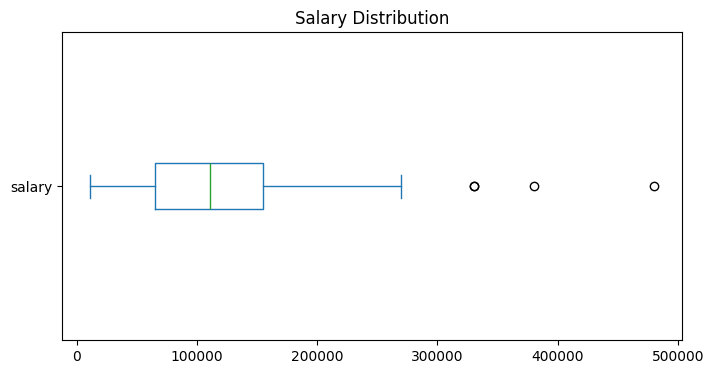

In [12]:
# Plot boxplot for 'salary'
# Chart title: Salary Distribution
# Plot Salary distribution
plt.figure(figsize=(8, 4))
df["salary"].plot(kind="box", vert=False)
plt.title("Salary Distribution")
plt.show()

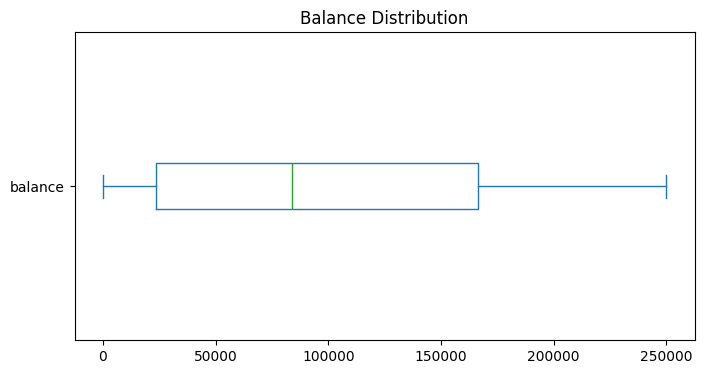

In [13]:
# Plot boxplot for 'balance'
# Chart title: Balance Distribution 
plt.figure(figsize=(8, 4))
df["balance"].plot(kind="box", vert=False)
plt.title("Balance Distribution")
plt.show()

In [14]:
# Identify and count outliers in salary using IQR method
 #  Calculate IQR for Salary
Q1 = df["salary"].quantile(0.25) 
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Identify outliers
salary_outliers = df[(df["salary"] < lower_bound) | (df["salary"] > upper_bound)]

print("Outlier Customers Based on Salary:")
print(salary_outliers[["salary"]])

outlier_count = ((df["salary"] < lower_bound) | (df["salary"] > upper_bound)).sum()
print("Count of Outlier Customers Based on Salary:", outlier_count)

Outlier Customers Based on Salary:
      salary
2   330000.0
36  480000.0
46  330000.0
59  380000.0
Count of Outlier Customers Based on Salary: 4


In [15]:
# Cap salary outliers at the upper bound
import numpy as np
df["salary"] = np.where(df["salary"] > upper_bound, upper_bound, df["salary"])

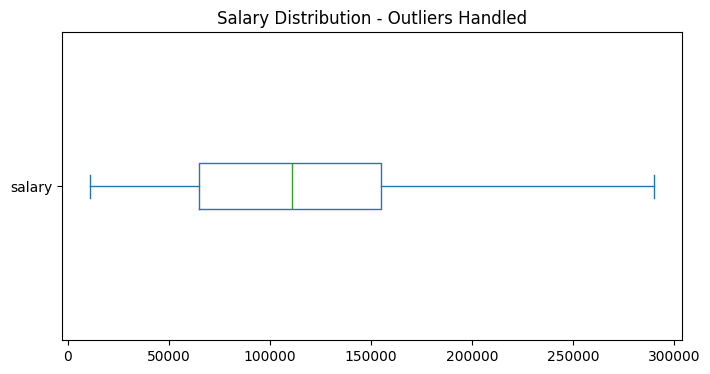

In [16]:

# Plot Salary distribution after handling outiers
# Chart title: Salary Distribution - Outliers Handled

# Plot Salary distribution
plt.figure(figsize=(8, 4))
df["salary"].plot(kind="box", vert=False)
plt.title("Salary Distribution - Outliers Handled")
plt.show()


## Exploratory Data Analysis

In [17]:
# Calculate Basic Summary Statistics
# Compute the mean and median for key numeric columns: Salary , Balance and Credit Score
# Print the results for interpretation.


mean_salary = round(df["salary"].mean())
median_salary = round(df["salary"].median())

mean_balance = round(df["balance"].mean())
median_balance = round(df["balance"].median())

mean_credit_score = round(df["credit_score"].mean())
median_credit_score = round(df["credit_score"].median())

# Display results
print(f"Mean Salary: {mean_salary}, Median Salary: {median_salary}")
print(f"Mean Balance: {mean_balance}, Median Balance: {median_balance}")
print(f"Mean Credit Score: {mean_credit_score}, Median Credit Score: {median_credit_score}")

Mean Salary: 110152, Median Salary: 111000
Mean Balance: 96958, Median Balance: 84081
Mean Credit Score: 670, Median Credit Score: 683


In [18]:
# Understand Categorical Variables
# Count and display how many customers fall into each category of: Gender, Card Type, HasLoan, HasFD

# Count of each category
gender_count = df["gender"].value_counts()
card_type_count = df["card_type"].value_counts()
loan_status_count = df["hasloan"].value_counts()
fd_status_count = df["hasfd"].value_counts()

# Display results
print("Gender Distribution:\n", gender_count)
print("\nCard Type Distribution:\n", card_type_count)
print("\nLoan Status Distribution:\n", loan_status_count)
print("\nFixed Deposit Status Distribution:\n", fd_status_count)

Gender Distribution:
 gender
Male      9028
Female    5965
Name: count, dtype: int64

Card Type Distribution:
 card_type
SILVER            4366
GOLD              4033
PLATINUM          3398
NOT APPLICABLE    3196
Name: count, dtype: int64

Loan Status Distribution:
 hasloan
0    11520
1     3473
Name: count, dtype: int64

Fixed Deposit Status Distribution:
 hasfd
0    8355
1    6638
Name: count, dtype: int64


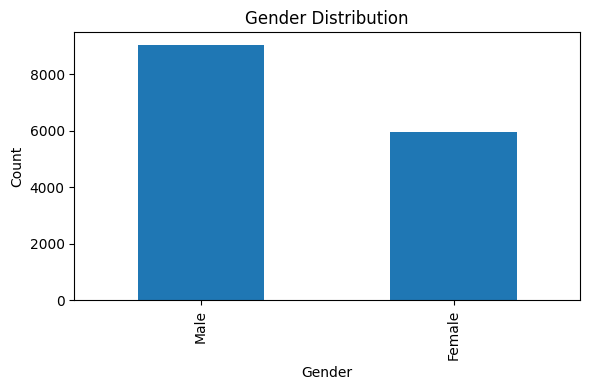

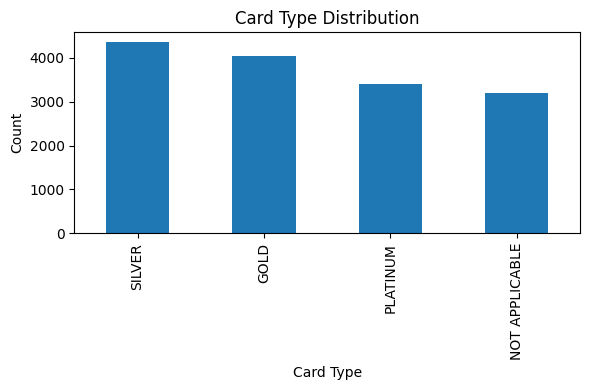

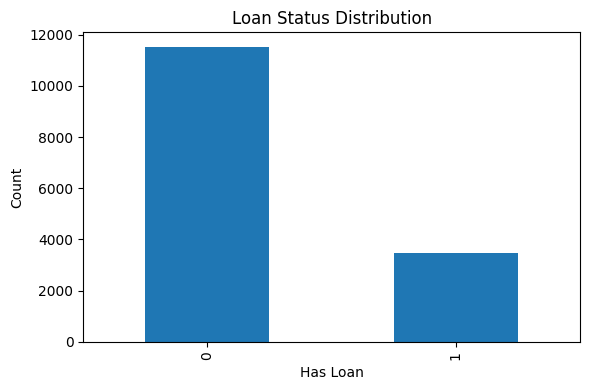

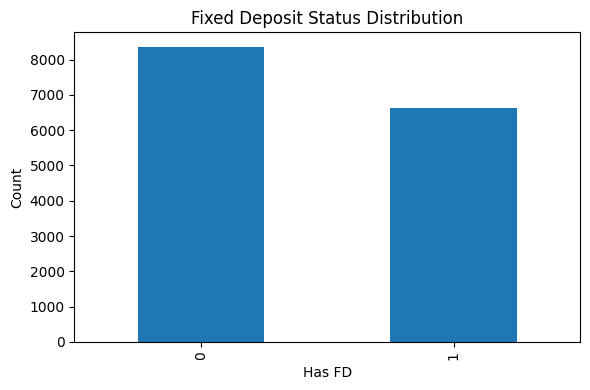

In [19]:
# PLot the above count distribution --> Optional 
import matplotlib.pyplot as plt

# Plot gender distribution
plt.figure(figsize=(6, 4))
gender_count.plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Plot card type distribution
plt.figure(figsize=(6, 4))
card_type_count.plot(kind='bar')
plt.title("Card Type Distribution")
plt.xlabel("Card Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Plot loan status distribution
plt.figure(figsize=(6, 4))
loan_status_count.plot(kind='bar')
plt.title("Loan Status Distribution")
plt.xlabel("Has Loan")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Plot fixed deposit status distribution
plt.figure(figsize=(6, 4))
fd_status_count.plot(kind='bar')
plt.title("Fixed Deposit Status Distribution")
plt.xlabel("Has FD")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

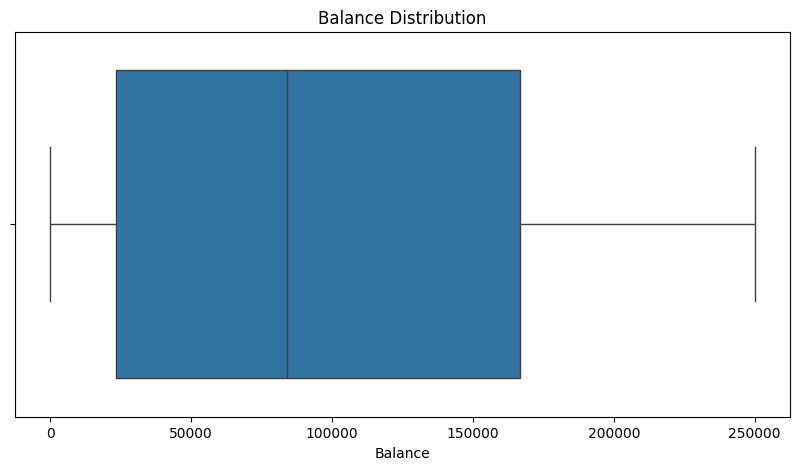

In [20]:
# Create a boxplot for the Balance column to detect outliers and understand spread.

import matplotlib.pyplot as plt
import seaborn as sns

# Balance using boxplots
plt.figure(figsize=(10,5))
sns.boxplot(x=df["balance"])
plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.show()


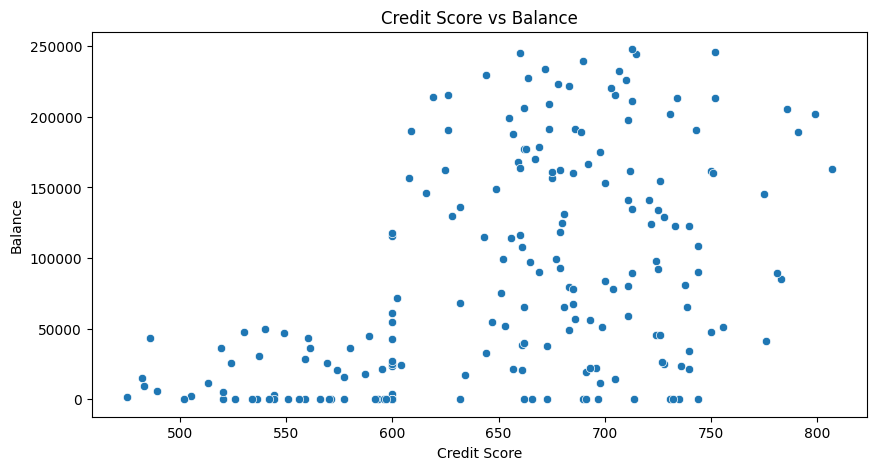

In [21]:
# Select a random sample of 200 customers from the dataset.
# Plot scatter plots to explore how two numeric variables relate to each other, plot for Credit Score vs Balance


# Subset of data (random sampling) around 200 datapoints are taken here
df_sample = df.sample(n=200, random_state=42)

# Scatter plot to detect anomalies in Credit Score vs Balance
plt.figure(figsize=(10,5))
sns.scatterplot(x=df_sample["credit_score"], y=df_sample["balance"])
plt.title("Credit Score vs Balance")
plt.xlabel("Credit Score")
plt.ylabel("Balance")
plt.show()

## Feature Engineering

In [22]:
# Add the following new columns to the dataset:
# Debt-to-Income Ratio
#  Formula: (Balance + (HasLoan × Salary × 0.3)) / Salary

# 1. Financial Stability Indicator
df["Debt-to-Income Ratio"] = (df["balance"] + (df["hasloan"] * df["salary"] * 0.3)) / df["salary"]

print(df[["first_name", "Debt-to-Income Ratio"]].tail())

      first_name  Debt-to-Income Ratio
14994    Anirudh              1.267763
14995     Sanjay              0.233106
14996     Kavita              0.526083
14997    Anirudh              0.695548
14998      Arjun              1.446423


In [23]:
# Create new column calculating Loyalty Score
# Formula: (Tenure × Satisfaction Score) / (1 + Count of Complains)

df["Loyalty Score"] = (df["tenure"] * df["satisfaction_score"]) / (1 + df["count_of_complains"])

# Display dataset with new features
print(df.head())

   row_number customer_id first_name        state  gender  age    salary  \
0           2     MH00002      Nitya  Maharashtra  Female   77   33000.0   
1           3     KA00003     Vivaan    Karnataka    Male   78  190000.0   
2           4     MH00004     Dinesh  Maharashtra    Male   42  290000.0   
3           5     KA00005     Charvi    Karnataka  Female   29  155000.0   
4           6     DL00006      Aditi        Delhi  Female   38  111000.0   

   credit_score  tenure    balance  ...  num_of_products isactivemember  \
0           538       4       0.00  ...                1              0   
1           531       8   15585.55  ...                2              1   
2           718       3  155688.22  ...                2              1   
3           710       7   89415.53  ...                2              1   
4           729       2   36613.80  ...                2              1   

   exited  complain  count_of_complains  satisfaction_score  point_earned  \
0       1      

## Analyze Complaints by State

In [24]:
# Compute the average number of complaints per state using groupby() and transform().

df["State Avg Complaints"] = df.groupby("state")["count_of_complains"].transform("mean")

In [25]:
# For each customer, compare their complaint count to their state’s average.
# Create a flag called High Complainer:
# 1 if their complaints are above the state average
# 0 otherwise
df["Above State Avg Complaints"] = df["count_of_complains"] > df["State Avg Complaints"]

df["High Complainer"] = df["Above State Avg Complaints"].astype(int)


In [26]:
# Print first 10 rows with updated data to see the difference
df.head(10)

,row_number,customer_id,first_name,state,gender,age,salary,credit_score,tenure,balance,...,complain,count_of_complains,satisfaction_score,point_earned,preferred_channel,Debt-to-Income Ratio,Loyalty Score,State Avg Complaints,Above State Avg Complaints,High Complainer
0,2,MH00002,Nitya,Maharashtra,Female,77,33000.0,538,4,0.00,...,0,0,5.0,100,Mobile,0.000000,20.000000,4.235927,False,0
1,3,KA00003,Vivaan,Karnataka,Male,78,190000.0,531,8,15585.55,...,0,0,10.0,150,Mobile,0.082029,80.000000,4.297710,False,0
2,4,MH00004,Dinesh,Maharashtra,Male,42,290000.0,718,3,155688.22,...,0,0,10.0,150,Phone,0.536856,30.000000,4.235927,False,0
3,5,KA00005,Charvi,Karnataka,Female,29,155000.0,710,7,89415.53,...,0,0,4.0,90,Branch,0.576874,28.000000,4.297710,False,0
4,6,DL00006,Aditi,Delhi,Female,38,111000.0,729,2,36613.80,...,0,0,4.0,90,Email,0.629854,8.000000,4.317580,False,0
5,7,DL00007,Yash,Delhi,Male,76,51000.0,585,2,0.00,...,1,30,1.0,0,Phone,0.300000,0.064516,4.317580,True,1
6,8,MH00008,Ishaan,Maharashtra,Male,30,68000.0,718,2,176184.65,...,0,0,8.0,130,Branch,2.590951,16.000000,4.235927,False,0
7,9,MH00009,Dinesh,Maharashtra,Male,41,145000.0,677,2,44774.77,...,0,0,9.0,140,Email,0.308792,18.000000,4.235927,False,0
8,10,WB00010,Krishna,West Bengal,Male,40,151000.0,695,10,176995.07,...,0,0,9.0,140,Email,1.172153,90.000000,4.188338,False,0
9,11,TN00011,Meenal,Tamil Nadu,Female,77,12000.0,508,3,0.00,...,0,0,6.0,110,Email,0.000000,18.000000,4.055290,False,0


## Univariate Analysis: Categorize customers by Salary

Salary Category
Very High        4180
High             4154
Medium           4070
Low              2583
Above 2 Lakhs       6
Name: count, dtype: int64


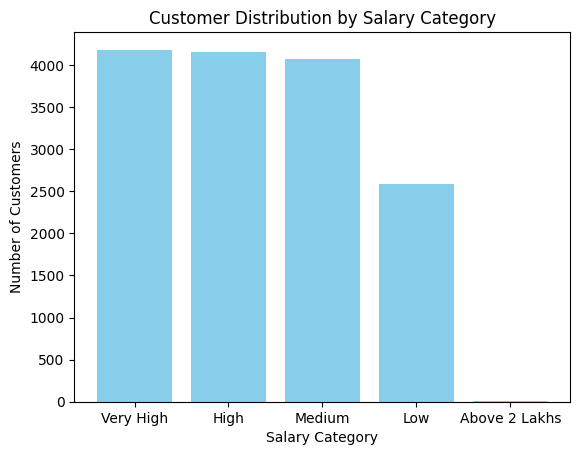

In [27]:
# Create a new column called Salary Category with the following buckets:
# Low (≤ 50,000)
# Medium (50,001 – 100,000)
# High (100,001 – 150,000)
# Very High (150,001 – 200,000)
# Above 2 Lakhs (> 200,000)
# Count how many customers fall into each group and plot the result.


df["Salary Category"] = np.where(df["salary"] <= 50000, "Low",
                         np.where(df["salary"] <= 100000, "Medium",
                         np.where(df["salary"] <= 150000, "High",
                         np.where(df["salary"] <= 200000, "Very High", "Above 2 Lakhs"))))

# Count customers in each category
salary_counts = df["Salary Category"].value_counts()

# series datatype
print(salary_counts)

# Plot salary distribution
# Here, index indicates the labels and values indicate total no of customers that fall into that label
plt.bar(salary_counts.index, salary_counts.values, color="skyblue")
plt.xlabel("Salary Category")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Salary Category")
plt.show()


## Compare Customer Segments Using Grouped Statistics

## Bivariate Analysis

In [28]:
# Calculate Average Number of Products Based on Customer Tenure

tenure_product_analysis = df.groupby("tenure")["num_of_products"].mean()
# Display results
print("Average Number of Products Based on Customer Tenure:")
print(tenure_product_analysis)

Average Number of Products Based on Customer Tenure:
tenure
1     1.433551
2     1.444779
3     1.437894
4     1.476880
5     1.495677
6     1.490417
7     1.368132
8     1.481707
9     1.511556
10    1.514377
Name: num_of_products, dtype: float64


## Multivariate Analysis

In [29]:
# Grouping by churn status to analyze salary and product usage
churn_analysis = df.groupby("exited")[["salary", "num_of_products"]].mean()
print(churn_analysis)

               salary  num_of_products
exited                                
0       115263.672522         1.509778
1        89064.273504         1.260171


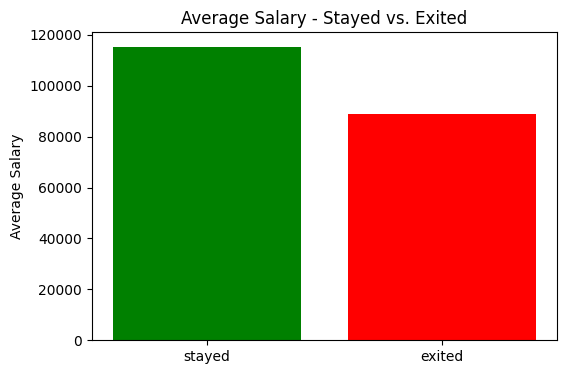

In [30]:
# Bar chart to compare salary for exited vs. retained customers
plt.figure(figsize=(6, 4))
plt.bar(["stayed", "exited"], churn_analysis["salary"], color=["green", "red"])
plt.title("Average Salary - Stayed vs. Exited")
plt.ylabel("Average Salary")
plt.show()


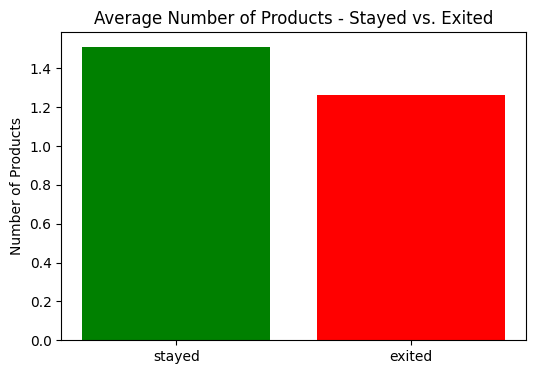

In [31]:
# Bar chart to compare product usage for exited vs. retained customers
plt.figure(figsize=(6, 4))
plt.bar(["stayed", "exited"], churn_analysis["num_of_products"], color=["green", "red"])
plt.title("Average Number of Products - Stayed vs. Exited")
plt.ylabel("Number of Products")
plt.show()

# Demographic Analysis

Demographic factors are measurable characteristics of a population, typically used to segment and understand customers better.
Without understanding these factors, companies may:
- Offer generic solutions that don’t resonate with specific customer segments.
- Miss out on early signs of churn in high-risk groups.
- Fail to optimize marketing campaigns for the right audiences.


In [33]:
# The dataset got updated and we have a new version though this is in cleaned format already with the missing values handled
import pandas as pd

# Load the dataset
df = pd.read_csv("https://gitlab.crio.do/me_notebook/me_jupyter_bankattritionanalysis/-/raw/master/bank_dataset_v3.csv",header=0,skiprows=[1])

# Display the first few rows
print(df.head())

   rownumber customerid first_name        state  gender  age  tenure  \
0          2    MH00002      Rohan  Maharashtra    Male   54       4   
1          3    KA00003     Ananya    Karnataka  Female   58       1   
2          4    MH00004    Nandini  Maharashtra  Female   39       2   
3          5    WB00005     Charvi  West Bengal  Female   25       3   
4          6    KA00006      Ritik    Karnataka    Male   48       3   

   creditscore    balance  hascrcard  ...  salary  exited  complain  \
0          600  163508.11          1  ...   62000       0         0   
1          724  138773.12          1  ...   97000       0         0   
2          695  136048.53          1  ...  157000       0         0   
3          675   27798.19          0  ...  146000       0         0   
4          600  181554.57          1  ...  102000       0         0   

   numcomplain  satisfaction_score  point_earned  preferredchannel    region  \
0            0                  10           150            

### 1. Visualize customers by churn status

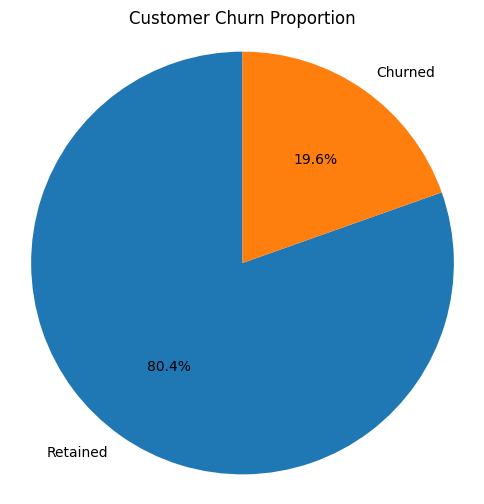

In [34]:
# TODO: 
# 1. Count the number of churned and non-churned customers using value_counts() on the 'exited' column.
# 2. Create labels for the pie chart, 'Retained' for non-churned and 'Churned' for exited customers.
# 3. Generate a pie chart to visualize the proportion of churned vs. retained customers. 
#    - Display the labels on the pie chart with percentages formatted to 1 decimal place.
#    - Add a title "Customer Churn Proportion".
import matplotlib.pyplot as plt
import pandas as pd

# Assuming your data is in a DataFrame called df, and churn is represented by column 'exited'
# 1. Count the number of churned vs non-churned
counts = df['exited'].value_counts()  # yields a Series, e.g. {0: count_non_churn, 1: count_churn}

# 2. Prepare labels matching the values 0 and 1
labels = ['Retained', 'Churned']
# However, ensure that the order of counts matches the labels; so align:
# If counts.index is [0,1], then the mapping is correct; else reindex
counts = counts.reindex([0, 1])  # ensures the order is (0 then 1)

# 3. Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    counts.values, 
    labels=labels, 
    autopct='%1.1f%%',      # format percentages to 1 decimal place
    startangle=90,          # optional: rotate so the first slice starts at 90°
    # You can also use other aesthetic params like shadow=True, explode, etc.
)
plt.title("Customer Churn Proportion")
plt.axis('equal')  # ensures the pie is drawn as a circle

plt.show()


### 2. Churn variation across states

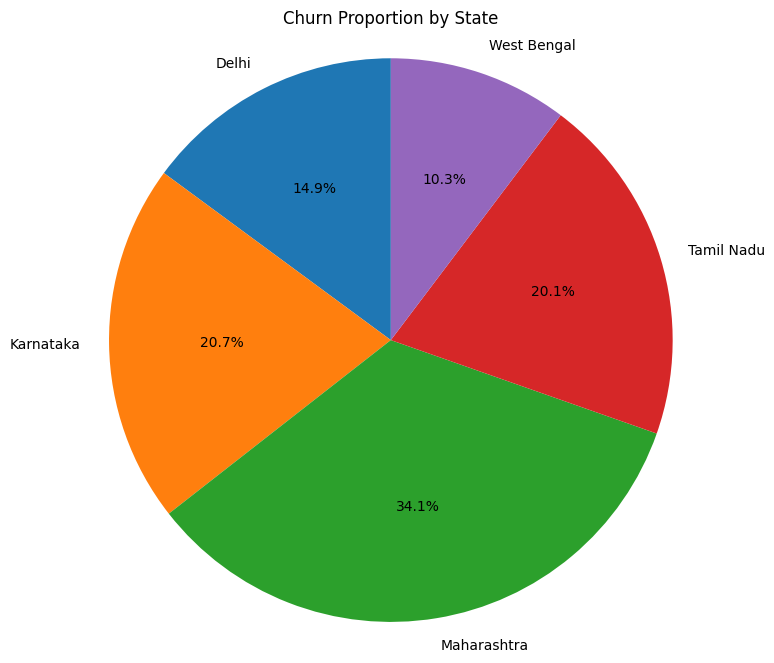

In [35]:
# TODO: 
# 1. Group the data based on the 'state' column using groupby().
# 2. Extract the 'exited' column for churned customers within each state.
# 3. Calculate the total number of churned customers per region by summing the 'exited' column for each group.
# 4. Plot a pie chart to visualize the churn distribution by region. 
#    - Display the percentages of churned customers for each region.
#    - Add a title "Churn Proportion by Region".
import matplotlib.pyplot as plt
import pandas as pd

# Assume your dataframe is df, and 'state' is the column holding regions/states

# 1. Group by 'state' and sum the 'exited' column to count churners in each state
churn_by_state = df.groupby('state')['exited'].sum()

# 2. (Optional) If some states have zero churn, you might want to drop them
#    churn_by_state = churn_by_state[churn_by_state > 0]

# 3. Prepare labels and values
labels = churn_by_state.index.tolist()
values = churn_by_state.values

# 4. Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Churn Proportion by State")
plt.axis('equal')  # to make the pie circular
plt.show()


### 3. Visualize age vs exit status

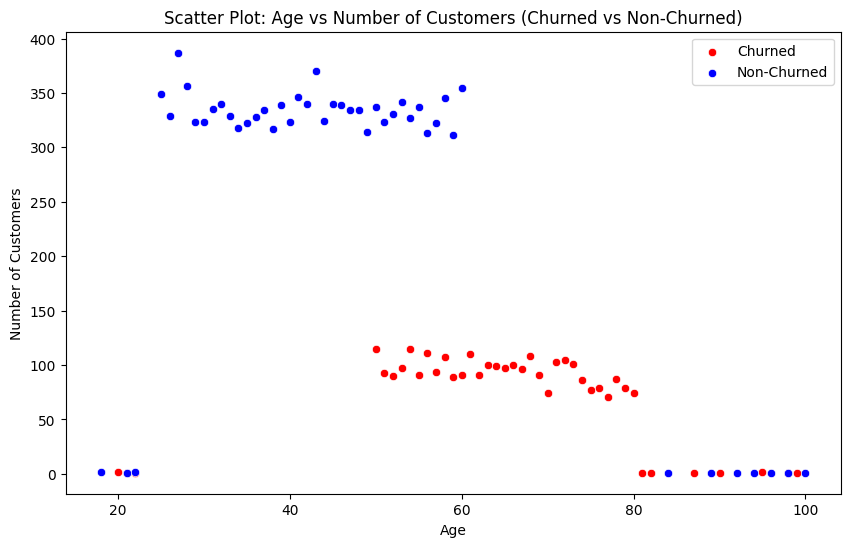

In [36]:
# TODO: 
# 1. Count the number of churned and non-churned customers by age:
#    - Filter the data for churned customers (exited == 1) and group by 'age', then count the occurrences.
#    - Filter the data for non-churned customers (exited == 0) and group by 'age', then count the occurrences.
# 2. Plot a scatter plot to visualize the number of churned vs non-churned customers across ages:
#    - Use red color for churned customers and blue for non-churned customers.
#    - Set the title to "Scatter Plot: Age vs Number of Customers (Churned vs Non-Churned)".
#    - Label the x-axis as "Age" and the y-axis as "Number of Customers".
#    - Add a legend to differentiate between churned and non-churned customers.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume your data is in a DataFrame called df, with columns 'age' and 'exited'

# 1. Count churned and non-churned customers by age

# a) For churned (exited == 1)
churned_by_age = df[df['exited'] == 1].groupby('age').size().reset_index(name='count')
# churned_by_age will have columns ['age', 'count']

# b) For non-churned (exited == 0)
nonchurned_by_age = df[df['exited'] == 0].groupby('age').size().reset_index(name='count')

# 2. Plot scatter plot

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=churned_by_age,
    x='age', y='count',
    color='red',
    label='Churned'
)
sns.scatterplot(
    data=nonchurned_by_age,
    x='age', y='count',
    color='blue',
    label='Non-Churned'
)

plt.title("Scatter Plot: Age vs Number of Customers (Churned vs Non-Churned)")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()


### 4. Visualize age-distribution and exit status

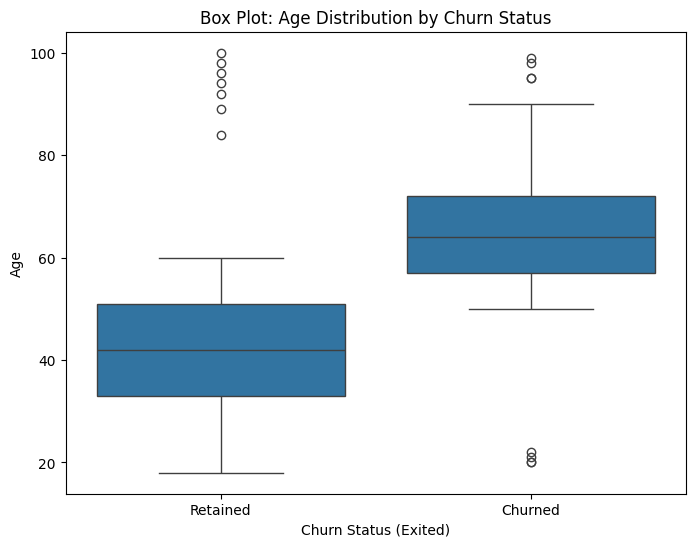

In [37]:
# TODO: 
# 1. Create a box plot to visualize the distribution of age by churn status:
#    - Use the 'exited' column for the x-axis (churn status) and the 'age' column for the y-axis (age distribution).
#    - Set the title to "Box Plot: Age Distribution by Churn Status".
#    - Label the x-axis as "Churn Status (Exited)".
#    - Label the y-axis as "Age".
import matplotlib.pyplot as plt
import seaborn as sns

# Assume your DataFrame is df with columns 'age' and 'exited'

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x='exited',    # categorical churn status (0 or 1)
    y='age'         # continuous age variable
)

plt.title("Box Plot: Age Distribution by Churn Status")
plt.xlabel("Churn Status (Exited)")
plt.ylabel("Age")

# Optionally: set x-tick labels to more descriptive names
plt.xticks([0, 1], ['Retained', 'Churned'])

plt.show()


### 5. Visualize gender and exit status

/tmp/ipykernel_50/240267019.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


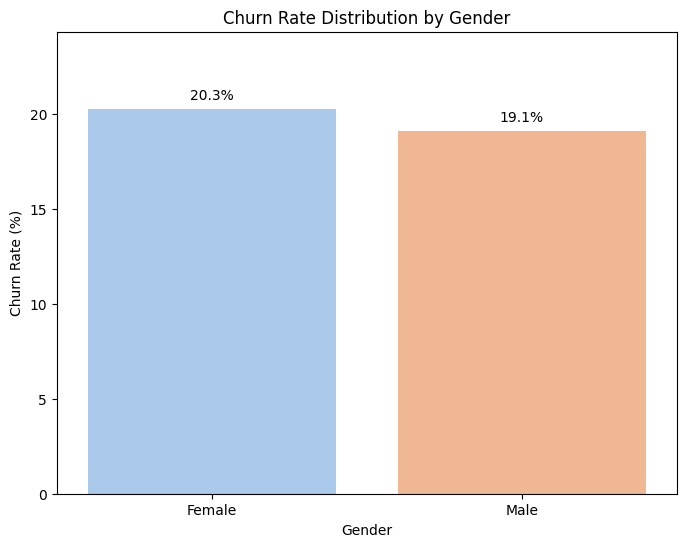

In [38]:
# TODO:
# 1. Filter the dataset to get only customers who have exited (churned) by using the 'exited' column.
# 2. Count the total number of customers per gender by grouping the data by 'gender' and counting the 'exited' column.
# 3. Count the number of churned customers per gender by filtering for churned customers and grouping by 'gender'.
# 4. Calculate the churn rate per gender manually:
#    - Divide the number of churned customers by the total number of customers per gender, then multiply by 100 to get the percentage.
# 5. Plot a bar plot to visualize the churn rate by gender:
#    - Plot the churn rate values against gender on the x-axis.
#    - Set the title to "Churn Rate Distribution by Gender".
#    - Label the x-axis as "Gender" and the y-axis as "Churn Rate (%)".

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume your DataFrame is df with columns 'gender' and 'exited'

# 1. Total number of customers per gender
total_by_gender = df.groupby('gender')['exited'].count().reset_index(name='total_count')
# Alternatively: df['gender'].value_counts()

# 2. Number of churned customers per gender (exited == 1)
churned_by_gender = df[df['exited'] == 1].groupby('gender')['exited'].count().reset_index(name='churned_count')

# 3. Merge the two DataFrames on gender
gender_stats = pd.merge(total_by_gender, churned_by_gender, on='gender', how='left')
# For any gender with zero churn, churned_count may be NaN; fill with 0
gender_stats['churned_count'] = gender_stats['churned_count'].fillna(0)

# 4. Calculate churn rate (%) per gender
gender_stats['churn_rate_pct'] = (gender_stats['churned_count'] / gender_stats['total_count']) * 100

# 5. Plot a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(
    data=gender_stats,
    x='gender',
    y='churn_rate_pct',
    palette='pastel'
)

plt.title("Churn Rate Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
# Optionally, annotate the bars with the percentages
for idx, row in gender_stats.iterrows():
    plt.text(idx, row['churn_rate_pct'] + 0.5, f"{row['churn_rate_pct']:.1f}%", ha='center')

plt.ylim(0, gender_stats['churn_rate_pct'].max() * 1.2)  # add some headroom
plt.show()


### 6. Churn Rate by State and Gender

<Figure size 1200x600 with 0 Axes>

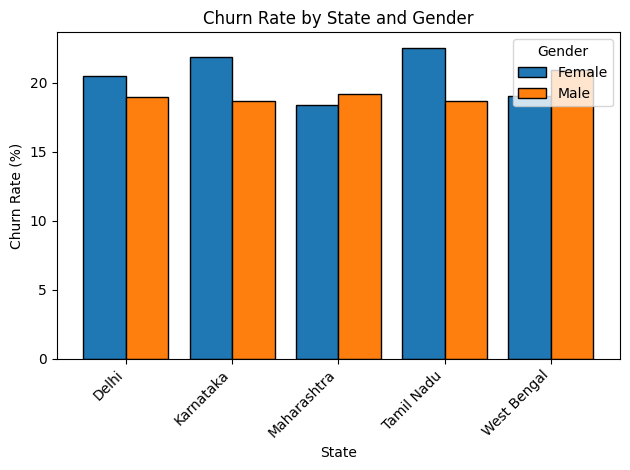

In [42]:
# TODO:
# 1. Group the data by both 'state' and 'gender' using the groupby() function.
# 2. Count the total number of customers in each group by counting the 'exited' column for each group.
# 3. Count the churned customers in each group by summing the 'exited' column (since 'exited' is 1 for churned customers).
# 4. Calculate the churn rate for each group manually:
#    - Divide the number of churned customers by the total number of customers in each group, then multiply by 100 to get the percentage.
# 5. Unstack the churn rate to separate the data by gender for better visualization in the plot.
# 6. Plot a bar chart to visualize the churn rate by state and gender:
#    - Use a bar plot with black edges around the bars.
#    - Set the title to 'Churn Rate by State and Gender'.
#    - Label the x-axis as 'State' and the y-axis as 'Churn Rate (%)'.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume your DataFrame is df with columns: 'state', 'gender', 'exited'

# 1. Total customers by (state, gender)
total_by_state_gender = (
    df.groupby(['state', 'gender'])['exited']
    .count()
    .reset_index(name='total_count')
)

# 2. Churned (exited == 1) customers by (state, gender)
churned_by_state_gender = (
    df[df['exited'] == 1]
    .groupby(['state', 'gender'])['exited']
    .sum()
    .reset_index(name='churned_count')
)

# 3. Merge totals with churned
state_gender_stats = pd.merge(
    total_by_state_gender, churned_by_state_gender,
    on=['state', 'gender'], how='left'
)
state_gender_stats['churned_count'] = state_gender_stats['churned_count'].fillna(0)

# 4. Compute churn rate (%)
state_gender_stats['churn_rate_pct'] = (
    state_gender_stats['churned_count'] / state_gender_stats['total_count']
) * 100

# 5. Pivot or unstack to have genders as separate columns for plotting
churn_rate_pivot = state_gender_stats.pivot(
    index='state', columns='gender', values='churn_rate_pct'
)

# Optional: sort states or drop states with negligible data
# churn_rate_pivot = churn_rate_pivot.sort_index()

# 6. Plot grouped bar chart
plt.figure(figsize=(12, 6))

# Use pandas plotting or seaborn
# If using pandas:
churn_rate_pivot.plot(
    kind='bar',
    edgecolor='black',
    width=0.8  # reduce width so bars don't touch
)

plt.title("Churn Rate by State and Gender")
plt.xlabel("State")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')

plt.tight_layout()
plt.show()


### 7. Relationship between income groups - salary and churn rate.

/tmp/ipykernel_50/3644070188.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_by_income = df.groupby('income_group')['exited'].count().reset_index(name='total_count')
/tmp/ipykernel_50/3644070188.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churned_by_income = df.groupby('income_group')['exited'].sum().reset_index(name='churned_count')
/tmp/ipykernel_50/3644070188.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


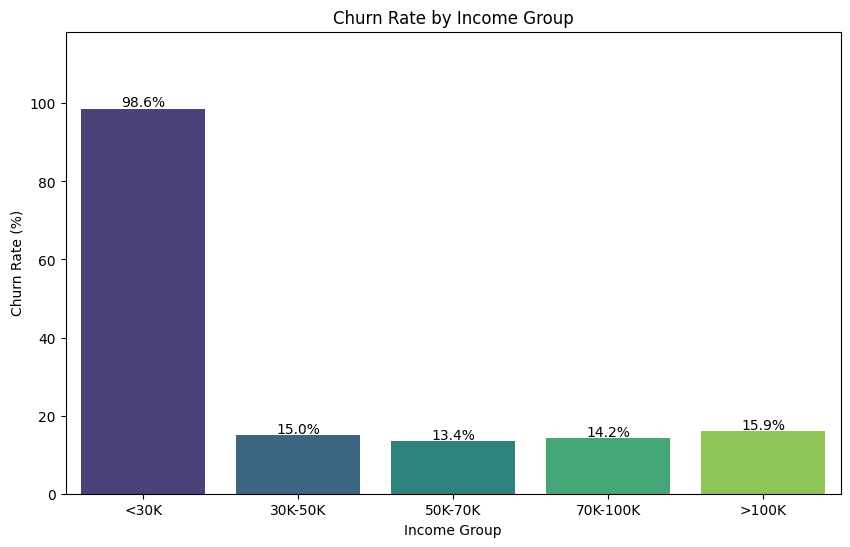

In [43]:
# TODO:
# 1. Create income bins (ranges) to categorize customers by income:
#    - Define the bins as [0, 30000, 50000, 70000, 100000, 150000] to represent different income ranges.
#    - Label the bins as '<30K', '30K-50K', '50K-70K', '70K-100K', '>100K'.
# 2. Assign customers to income groups based on their salary using the pd.cut() function and the defined bins and labels.
# 3. Count the total number of customers in each income group by grouping by 'income_group' and counting the 'exited' column.
# 4. Count the number of churned customers in each income group by grouping by 'income_group' and summing the 'exited' column.
# 5. Calculate the churn rate for each income group manually:
#    - Divide the number of churned customers by the total number of customers in each income group, then multiply by 100 to get the percentage.
# 6. Plot a bar chart to visualize the churn rate by income group:
#    - Use a bar chart to display the churn rate for each income group.
#    - Set the title to 'Churn Rate by Income Group'.
#    - Label the x-axis as 'Income Group' and the y-axis as 'Churn Rate (%)'.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume your DataFrame is df, and there is a numeric column 'salary' (or ‘income’, whatever your column name is)
# Adjust the column name if it's not 'salary'

# 1. Define income bins and labels
bins = [0, 30000, 50000, 70000, 100000, 150000]
labels = ['<30K', '30K-50K', '50K-70K', '70K-100K', '>100K']

# 2. Create a new column ‘income_group’ classifying each customer
df['income_group'] = pd.cut(df['salary'], bins=bins, labels=labels, include_lowest=True)

# 3. Total customers per income group
total_by_income = df.groupby('income_group')['exited'].count().reset_index(name='total_count')

# 4. Churned customers per income group (sum of exited)
churned_by_income = df.groupby('income_group')['exited'].sum().reset_index(name='churned_count')

# 5. Merge totals and churned
income_stats = pd.merge(total_by_income, churned_by_income, on='income_group', how='left')
income_stats['churned_count'] = income_stats['churned_count'].fillna(0)

# 6. Compute churn rate (%) for each income group
income_stats['churn_rate_pct'] = (income_stats['churned_count'] / income_stats['total_count']) * 100

# 7. Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=income_stats,
    x='income_group',
    y='churn_rate_pct',
    palette='viridis'
)

plt.title("Churn Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Churn Rate (%)")

# Optional: annotate percentages on bars
for idx, row in income_stats.iterrows():
    plt.text(idx, row['churn_rate_pct'] + 0.5, f"{row['churn_rate_pct']:.1f}%", ha='center')

plt.ylim(0, income_stats['churn_rate_pct'].max() * 1.2)
plt.show()


In [55]:
# TODO:
# 1. Define bins and labels for age groups:
#    - Set the age bins as [18, 30, 45, 60, 100] to categorize customers into different age ranges.
#    - Define the corresponding labels for these age ranges as ['18-30', '31-45', '46-60', '60+'].
# 2. Apply pd.cut() to create age groups in the 'age_group' column:
#    - Use the defined age bins and labels, and set right=False to include the left endpoint of each bin.
# 3. Print the first few rows of the dataframe to verify the new 'age_group' column.
import pandas as pd

# Define your age bins and labels
age_bins = [18, 30, 45, 60, 100]  # boundaries for age groups
age_labels = ['18-30', '31-45', '46-60', '60+']

# Create 'age_group' column
df['age_group'] = pd.cut(
    df['age'], 
    bins=age_bins, 
    labels=age_labels, 
    right=False,        # so intervals are left-inclusive of start, exclude right boundary
    include_lowest=True # include the lowest boundary (so age == 18 goes into first bin)
)

# Optional: check the new column
print(df[['age', 'age_group']].head())
print(df['age_group'].value_counts(dropna=False))


   age age_group
0   54     46-60
1   58     46-60
2   39     31-45
3   25     18-30
4   48     46-60
age_group
46-60    5951
31-45    4988
60+      2288
18-30    1753
NaN         1
Name: count, dtype: int64


### 8. Churn rates across regions and genders

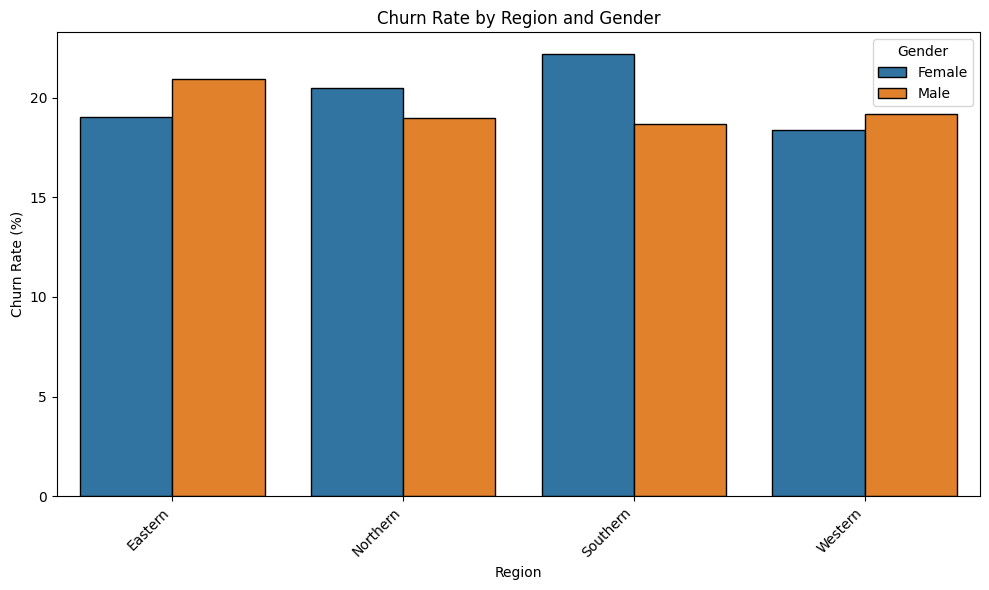

In [56]:
# TODO:
# 1. Group the data by 'region' and 'gender' using the groupby() function.
# 2. Count the total number of customers in each region-gender group by counting the 'exited' column.
# 3. Count the number of churned customers in each region-gender group by summing the 'exited' column (since 'exited' is 1 for churned customers).
# 4. Calculate the churn rate for each region-gender group manually:
#    - Divide the number of churned customers by the total number of customers in each group, then multiply by 100 to get the percentage.
# 5. Convert the churn rate series into a DataFrame for easier visualization by resetting the index and naming the new column 'churn_rate'.
# 6. Plot a bar chart to visualize the churn rate by region and gender:
#    - Use the 'region' column for the x-axis, 'churn_rate' for the y-axis, and 'gender' for the hue (legend) to differentiate between male and female.
#    - Set the title to 'Churn Rate by Region and Gender'.
#    - Label the x-axis as 'Region' and the y-axis as 'Churn Rate (%)'.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming your DataFrame is `df`, with columns: 'region', 'gender', and 'exited' (0/1)

# 1. Total customers per (region, gender)
total_rg = (
    df.groupby(['region', 'gender'])['exited']
    .count()
    .reset_index(name='total_count')
)

# 2. Churned customers per (region, gender) by summing exited
churned_rg = (
    df[df['exited'] == 1]
    .groupby(['region', 'gender'])['exited']
    .sum()
    .reset_index(name='churned_count')
)

# 3. Merge the two so that every (region, gender) has both total_count & churned_count
rg_stats = pd.merge(
    total_rg,
    churned_rg,
    on=['region', 'gender'],
    how='left'
)

# 4. Fill missing churned counts (if any) with zero
rg_stats['churned_count'] = rg_stats['churned_count'].fillna(0)

# 5. Compute churn rate (%) per group
rg_stats['churn_rate_pct'] = (
    rg_stats['churned_count'] / rg_stats['total_count']
) * 100

# 6. Plot using sns.barplot with region on x, churn_rate on y, and hue = gender
plt.figure(figsize=(10, 6))
sns.barplot(
    data=rg_stats,
    x='region',
    y='churn_rate_pct',
    hue='gender',
    edgecolor='black'
)

plt.title("Churn Rate by Region and Gender")
plt.xlabel("Region")
plt.ylabel("Churn Rate (%)")
plt.legend(title='Gender')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 9. Average satisfaction score for age groups

/tmp/ipykernel_50/3719637548.py:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_50/3719637548.py:29: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_50/3719637548.py:35: DeprecationWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead

/tmp/ipykernel_50/3719637548.py:43: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




  age_group  avg_satisfaction_score
0     18-30                2.750000
2     46-60                4.176647
3       60+                4.177997


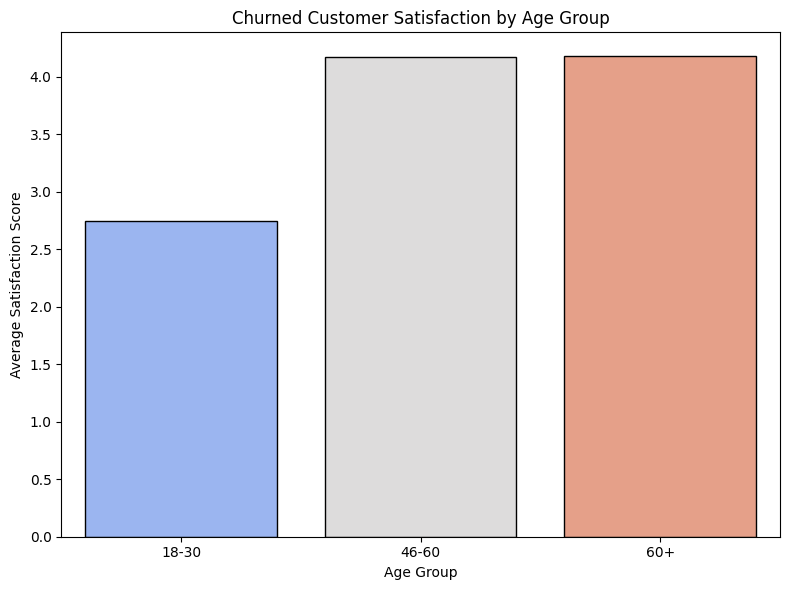

In [57]:
# TODO:
# 1. Filter the dataset to include only churned customers by selecting rows where 'exited' == 1.
# 2. Group the churned customers by 'age_group' and calculate the total number of churned customers in each group.
#    - Count the 'satisfaction_score' values for each 'age_group' to get the total churned customers per group.
# 3. Calculate the average satisfaction score for churned customers in each age group:
#    - Group the churned customers by 'age_group' and calculate the mean of the 'satisfaction_score' column.
#    - Reset the index and name the new column 'avg_satisfaction_score'.
# 4. Drop any rows where the 'avg_satisfaction_score' is NaN to clean up the data.
# 5. (Optional) Remove unused categories from the 'age_group' column if it's a categorical column with unused categories.
# 6. Print the resulting DataFrame to verify the data.
# 7. Plot a bar chart to visualize the average satisfaction score for churned customers by age group:
#    - Use 'age_group' for the x-axis and 'avg_satisfaction_score' for the y-axis.
#    - Set the title to 'Churned Customer Satisfaction by Age Group'.
#    - Label the x-axis as 'Age Group' and the y-axis as 'Average Satisfaction Score'.
# ✅ Step 9: Average Satisfaction Score for Age Groups

# --- Step 0: Create the 'age_group' column (if not already created) ---
age_bins = [18, 30, 45, 60, 100]
age_labels = ['18-30', '31-45', '46-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# 1. Filter the dataset to include only churned customers
churned_df = df[df['exited'] == 1]

# 2. Group by 'age_group' and count churned customers
churned_count = churned_df.groupby('age_group')['satisfaction_score'].count().reset_index(name='churned_count')

# 3. Calculate average satisfaction score for churned customers in each age group
avg_satisfaction = churned_df.groupby('age_group')['satisfaction_score'].mean().reset_index(name='avg_satisfaction_score')

# 4. Drop NaN values
avg_satisfaction = avg_satisfaction.dropna(subset=['avg_satisfaction_score'])

# 5. Remove unused categories if any
if pd.api.types.is_categorical_dtype(avg_satisfaction['age_group']):
    avg_satisfaction['age_group'] = avg_satisfaction['age_group'].cat.remove_unused_categories()

# 6. Print resulting DataFrame
print(avg_satisfaction)

# 7. Plot bar chart
plt.figure(figsize=(8,6))
sns.barplot(data=avg_satisfaction, x='age_group', y='avg_satisfaction_score', palette='coolwarm', edgecolor='black')

plt.title("Churned Customer Satisfaction by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Satisfaction Score")

plt.tight_layout()
plt.show()


### 10. Count of customers by employment type, highlighting churned vs non-churned customers.

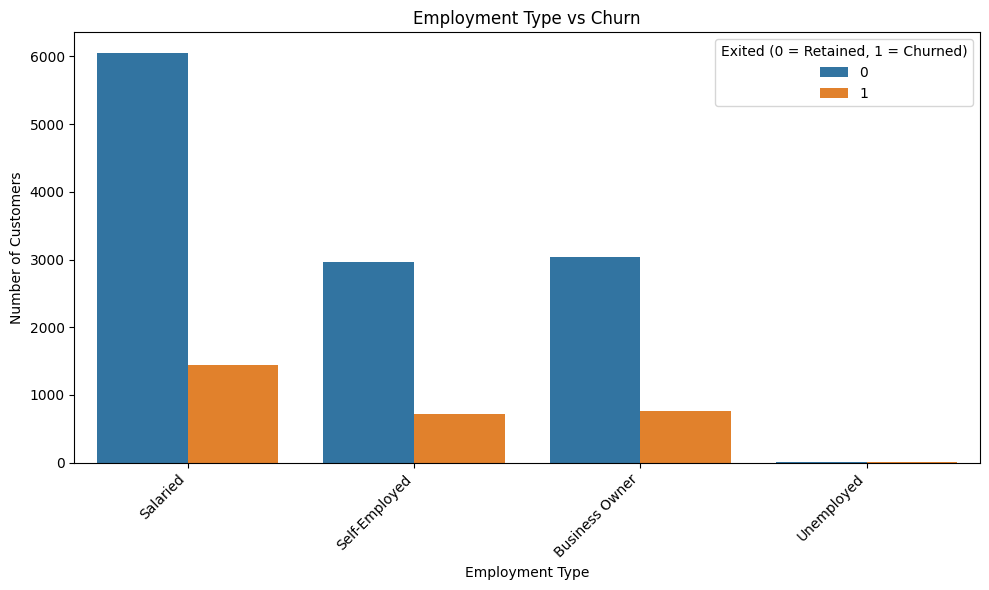

In [58]:
# TODO:
# 1. Group the data by 'employment_type' and 'exited' (churn status) and count the occurrences of each combination:
#    - Use groupby() to group by both 'employment_type' and 'exited', then apply size() to count the occurrences in each group.
#    - Reset the index of the result to make it easier to work with.
# 2. Create a count plot to visualize the relationship between 'employment_type' and churn status:
#    - Use 'employment_type' for the x-axis and 'exited' (churn status) for the hue to differentiate between churned and non-churned customers.
# 3. Customize the plot:
#    - Set the title to "Employment Type vs Churn".
#    - Label the x-axis as "Employment Type" and the y-axis as "Number of customers".
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume your DataFrame is df, with columns: 'employment_type' and 'exited'

# 1. (Optional) You can pre-compute counts, but not strictly necessary with countplot
# group_counts = (
#     df.groupby(['employment_type', 'exited'])
#       .size()
#       .reset_index(name='count')
# )
# print(group_counts)

# 2. Create a count plot 
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='employment_type',
    hue='exited'
)

plt.title("Employment Type vs Churn")
plt.xlabel("Employment Type")
plt.ylabel("Number of Customers")
plt.legend(title='Exited (0 = Retained, 1 = Churned)')  # you can customize legend labels if needed
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 11. Churn rates by region using Plotly

In [59]:
# TODO:
# 1. Group the data by 'state' using the groupby() function to categorize the customers by their region (state).
# 2. Count the total number of customers in each state by grouping by 'state' and counting the 'exited' column.
# 3. Count the number of churned customers in each state by grouping by 'state' and summing the 'exited' column (since 'exited' is 1 for churned customers).
# 4. Calculate the churn rate for each state manually:
#    - Divide the number of churned customers by the total number of customers in each state, then multiply by 100 to get the percentage.
# 5. Convert the churn rate series into a DataFrame for easier visualization by resetting the index and naming the new column 'churn_rate'.
# 6. Create a bar chart to visualize the churn rate by state using Plotly:
#    - Use the 'state' column for the x-axis and 'churn_rate' for the y-axis.
#    - Set the chart title to 'Churn Rate by State'.


import plotly.express as px
import plotly.io as pio

# Set default renderer for Plotly
pio.renderers.default = 'iframe'

import pandas as pd
import plotly.express as px

# — Assumptions —
# Your DataFrame is `df`
# Column for churn flag is 'exited' (1 = churn, 0 = stayed)
# State is stored in the column 'state'

# 1. Total number of customers per state
total_by_state = (
    df.groupby('state')['exited']
    .count()
    .reset_index(name='total_count')
)

# 2. Number of churned customers per state
churned_by_state = (
    df[df['exited'] == 1]
    .groupby('state')['exited']
    .sum()
    .reset_index(name='churned_count')
)

# 3. Merge totals + churned
state_stats = pd.merge(total_by_state, churned_by_state, on='state', how='left')
state_stats['churned_count'] = state_stats['churned_count'].fillna(0)

# 4. Compute churn rate (%) per state
state_stats['churn_rate'] = (state_stats['churned_count'] / state_stats['total_count']) * 100

# 5. (Optional) Sort states by churn rate descending for better ordering
state_stats = state_stats.sort_values(by='churn_rate', ascending=False)

# 6. Create bar chart with Plotly
fig = px.bar(
    state_stats,
    x='state',
    y='churn_rate',
    title="Churn Rate by State",
    labels={'churn_rate': 'Churn Rate (%)', 'state': 'State'},
    text=state_stats['churn_rate'].round(1).astype(str) + '%'
)

# Optional: format text to appear outside bars, adjust layout
fig.update_traces(textposition='outside')
fig.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')

fig.show()
